# Chapter 21: Variational Quantum Linear Solver --- Drivers

The Variational Quantum Linear Solver (VQLS) tackles the quantum linear system problem --- find $|u\rangle=|x/\|x\|\rangle$ where $A\mathbf{x}=\mathbf{b}$ --- with a hybrid quantum-classical loop (Book Chapter 21). A parametric **ansatz** generates trial states $|u(\theta)\rangle$, $A$ is expanded as a linear combination of Pauli operators, and a quantum **cost function** scores each trial (lowest when $A|u(\theta)\rangle\propto|b\rangle$); a classical optimizer searches for the best $\theta^{*}$.

The reusable class lives in `Chapter21_VQLS_functions.py`. It implements the **global cost**
$$C_G(\theta)=1-\frac{|\langle b|A|u(\theta)\rangle|^2}{\langle u(\theta)|A^\dagger A|u(\theta)\rangle},$$
evaluated exactly from the statevector. The numerator is measured as $\langle u|M|u\rangle$ with the Hermitian operator $M=A^\dagger|b\rangle\langle b|A$, since $|\langle b|A|u\rangle|^2=\langle u|M|u\rangle$.

**Simulator vs. hardware.** Forming $M$ requires the projector $|b\rangle\langle b|$ (i.e. knowing $b$ classically), which is fine for these statevector demonstrations but is exactly what a real device cannot do at scale. On hardware, $\langle b|A|u\rangle$ must be estimated with the ancilla-based **Hadamard test** of Book §21.4. VQLS is a NISQ-era variational method: no proven quantum advantage, prone to barren plateaus at scale, competitive only on problems already easy classically. See `Chapter02_QuantumSoftware.ipynb` for installation.

## Setup and imports

In [1]:
import numpy as np
from scipy.sparse import diags
from Chapter21_VQLS_functions import VQLS

## Choose from $A\mathbf{x}=\mathbf{b}$ examples  *(Book §21.8)*

Each option fixes a matrix $A$ and right-hand side $b$. Example 5 (with `p`) is deliberately ill-conditioned; example 6 is an $N=8$ tridiagonal (Poisson-like) matrix --- a discretized differential operator, the structured regime VQLS is actually suited to. Select one via `example`.

In [2]:
example = 2
if example == 1:
    A = np.array([[1, 0], [0, 1]]);            b = np.array([1, 0])
elif example == 2:
    A = np.array([[2, -1], [-1, 2]]);          b = np.array([1, 1]) / np.sqrt(2)
elif example == 3:
    A = np.array([[1, 0, 0, -0.5], [0, 1, 0, 0],
                  [0, 0, 1, 0], [-0.5, 0, 0, 1]]); b = np.array([1, 0, 0, 0])
elif example == 4:
    A = np.array([[1.5, 0.5], [0.5, 1.5]]);    b = np.array([1, 0])
elif example == 5:
    p = 1
    A = np.array([[5 * (10**p), -1], [-1, 5]]); b = np.array([1, 0])
elif example == 6:
    N = 8
    values = [-np.ones(N - 1), 2 * np.ones(N), -np.ones(N - 1)]
    A = diags(values, [-1, 0, 1]).toarray()
    b = np.zeros(N); b[0] = 1

print("A:\n", A)
print("b:\n", b)

A:
 [[ 2 -1]
 [-1  2]]
b:
 [0.70710678 0.70710678]


## Solve with the global cost  *(Book §21.1--21.2)*

We build a `VQLS` solver for the chosen system, minimize $C_G(\theta)$ with COBYLA, and compare the recovered $|u(\theta^*)\rangle$ against the classical solution by fidelity. For the $2\times2$ and $4\times4$ systems `reps=6` suffices; the $N=8$ Poisson matrix uses a deeper ansatz.

In [3]:
reps = 8 if A.shape[0] >= 8 else 6
solver = VQLS(A, b, reps=reps, entanglement='full')

u, result = solver.solve(seed=1, maxiter=4000)

x_exact = solver.classical_solution()
fid = solver.fidelity(x_exact, u)

print(f"Final cost        : {result.fun:.2e}")
print(f"Exact (normalized): {np.round(x_exact, 6)}")
print(f"Quantum solution  : {np.round(u.real, 6)}")
print(f"Solution fidelity : {fid:.4f}")

Final cost        : 7.46e-11
Exact (normalized): [0.707107 0.707107]
Quantum solution  : [0.707105 0.707109]
Solution fidelity : 1.0000


### Shot count and accuracy

The exact statevector cost above converges cleanly. On real hardware (or a shot-based estimator) the cost is noisy, and shot count directly controls accuracy: too few shots and the optimizer is misled near the minimum. Book §21.8 shows the same $4\times4$ system converging to a correct solution with 50,000 shots and a poor one with 10,000. The statevector solver here is the noise-free reference those runs are measured against.

## Illustrative examples: reproducing the figures  *(Book §21.8)*

The plots in the *VQLS Illustrative Examples* section are of two kinds:

- **Cost landscapes** $C_G(\theta)$ swept over $\theta$ (Examples 1--2). These are single-qubit systems, so we use a bare $R_Y(\theta)$ ansatz and $\theta$ is a genuine scalar --- the minima sit at $\theta^*=\pi$ and $\theta^*=\pi/2$.
- **COBYLA convergence** traces, $C_G$ vs. iteration (Examples 3--5), using the shipped `VQLS` class with a finite shot count.

The helper below sweeps the scalar cost; the two after it produce the landscape and convergence plots.

In [4]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize

def _scalar_ops(A, b):
    """Build M = A^dag |b><b| A and A^dag A (as matrices) for a 1-qubit system."""
    A = np.asarray(A, float); b = np.asarray(b, float); b = b / np.linalg.norm(b)
    P = SparsePauliOp.from_operator(A)
    b_proj = SparsePauliOp.from_operator(np.outer(b, b))
    M = P.adjoint().compose(b_proj).compose(P).simplify().to_matrix()
    AdA = P.adjoint().compose(P).simplify().to_matrix()
    return M, AdA

def _expectation(psi, Herm, nShots, rng):
    """<psi|Herm|psi> with genuine multinomial shot noise (exact if nShots is None).

    The observable is diagonalized; measuring in its eigenbasis gives outcome
    probabilities, from which nShots samples are drawn. This reproduces true
    1/sqrt(nShots) shot noise, so the 10000-shot curve is smooth and the
    1000-shot curve is visibly jagged.
    """
    w, V = np.linalg.eigh(Herm)
    probs = np.abs(V.conj().T @ psi) ** 2
    probs = probs / probs.sum()
    if nShots is None:
        return float(np.real(np.sum(probs * w)))
    counts = rng.multinomial(nShots, probs)
    return float(np.sum(counts / nShots * w))

def cost_scalar(theta, M, AdA, nShots=None, rng=None):
    """C_G for a single-qubit RY(theta) ansatz; exact or multinomial shot-based."""
    if rng is None:
        rng = np.random.default_rng()
    qc = QuantumCircuit(1); qc.ry(theta, 0)
    psi = Statevector(qc).data
    num = _expectation(psi, M, nShots, rng)
    den = _expectation(psi, AdA, nShots, rng)
    return 1.0 - num / den

### Cost landscapes (Examples 1--2)

Example 1 uses $A=\mathrm{diag}(1,0.75)$, $b=(0,1)$ (minimum at $\theta=\pi$); Example 2 uses $A=[[2,-1],[-1,2]]$, $b=(1,1)/\sqrt2$ (minimum at $\theta=\pi/2$). Compare $10000$ shots (smooth) against $1000$ shots (jagged).

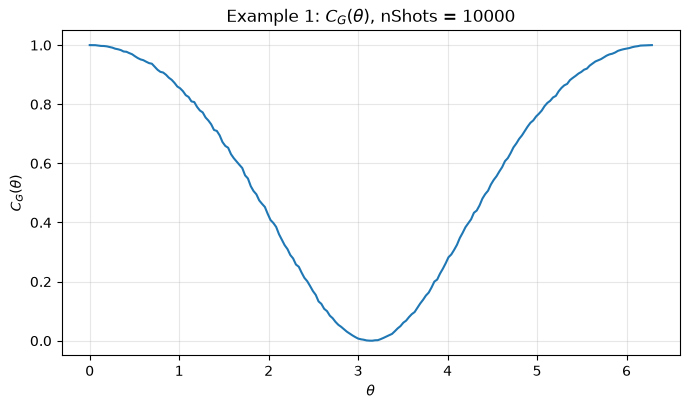

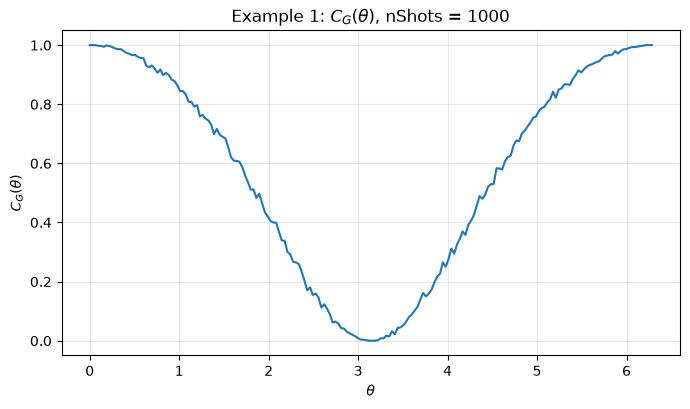

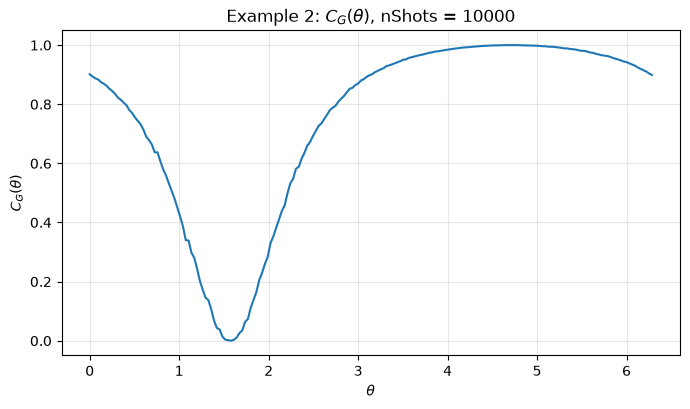

In [5]:
thetas = np.linspace(0, 2*np.pi, 200)

def plot_landscape(A, b, nShots, title, seed=0):
    M, AdA = _scalar_ops(A, b)
    rng = np.random.default_rng(seed)
    costs = [cost_scalar(t, M, AdA, nShots, rng) for t in thetas]
    plt.figure(figsize=(7, 4.2))
    plt.plot(thetas, costs, lw=1.5)
    plt.xlabel(r'$\theta$'); plt.ylabel(r'$C_G(\theta)$')
    plt.title(title); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

A1, b1 = [[1, 0], [0, 0.75]], [0, 1]          # Example 1
A2, b2 = [[2, -1], [-1, 2]], [1/np.sqrt(2), 1/np.sqrt(2)]  # Example 2

plot_landscape(A1, b1, 10000, 'Example 1: $C_G(\\theta)$, nShots = 10000')
plot_landscape(A1, b1, 1000,  'Example 1: $C_G(\\theta)$, nShots = 1000')
plot_landscape(A2, b2, 10000, 'Example 2: $C_G(\\theta)$, nShots = 10000')

### COBYLA convergence (Examples 3--5)

Using the shipped `VQLS` class, we log $C_G$ at every cost evaluation during a COBYLA run. Example 5 (the $4\times4$ system) is shown at $10000$ and $50000$ shots; the higher budget lowers the noise floor.

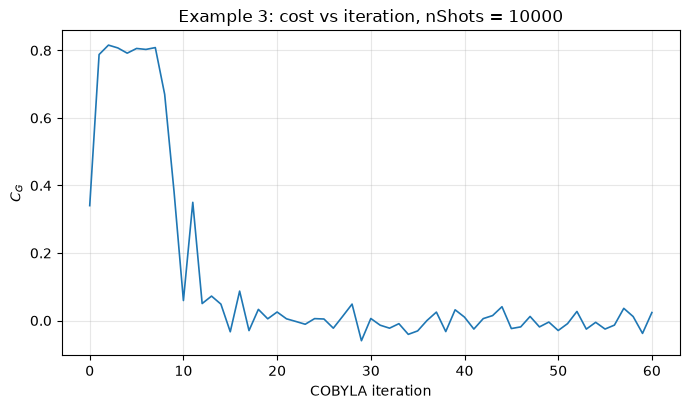

fidelity vs exact: 0.9738


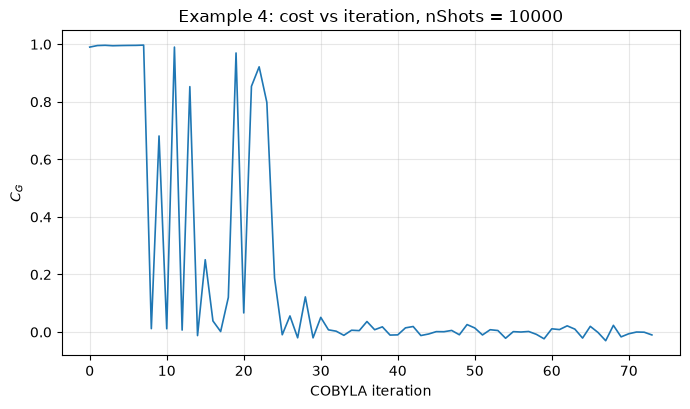

fidelity vs exact: 0.9998


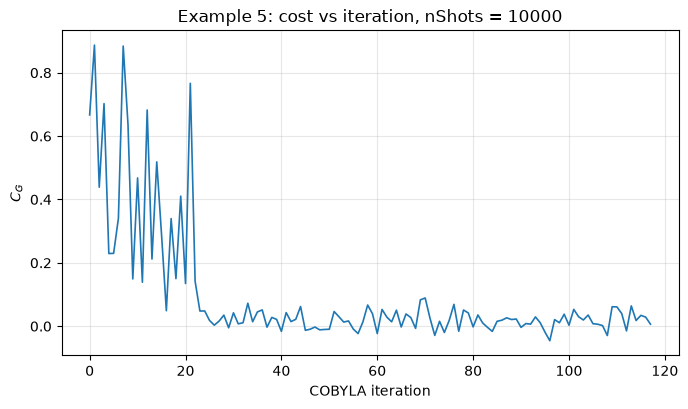

fidelity vs exact: 0.9681


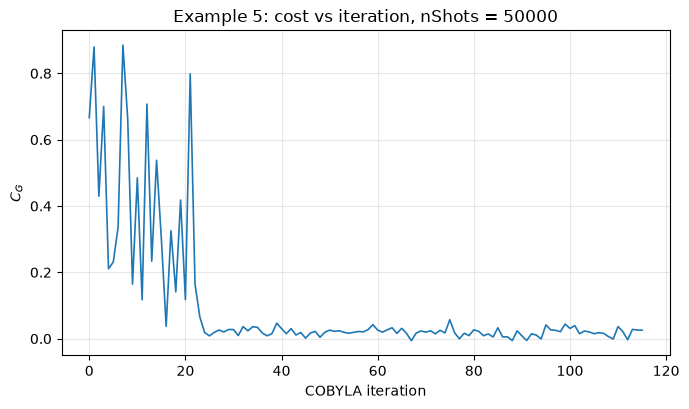

fidelity vs exact: 0.9958


In [6]:
def plot_convergence(A, b, nShots, title, reps=6, seed=1, maxiter=250):
    solver = VQLS(A, b, reps=reps, nShots=nShots)
    history = []
    theta0 = np.random.default_rng(seed).random(solver.ansatz.num_parameters)
    def logged(theta):
        c = solver.cost(theta); history.append(c); return c
    minimize(logged, theta0, method='COBYLA', options={'maxiter': maxiter})
    plt.figure(figsize=(7, 4.2))
    plt.plot(history, lw=1.2)
    plt.xlabel('COBYLA iteration'); plt.ylabel(r'$C_G$')
    plt.title(title); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    u, _ = solver.solve(seed=seed, maxiter=maxiter)
    print(f'fidelity vs exact: {solver.fidelity(solver.classical_solution(), u):.4f}')

# Examples 3 and 4 (2x2 systems)
plot_convergence(A1, b1, 10000, 'Example 3: cost vs iteration, nShots = 10000')
plot_convergence(A2, b2, 10000, 'Example 4: cost vs iteration, nShots = 10000')

# Example 5 (4x4 system), 10k vs 50k shots
A3 = [[1, 0, 0, -0.5], [0, 1, 0, 0], [0, 0, 1, 0], [-0.5, 0, 0, 1]]
b3 = [1, 0, 0, 0]
plot_convergence(A3, b3, 10000, 'Example 5: cost vs iteration, nShots = 10000', maxiter=300)
plot_convergence(A3, b3, 50000, 'Example 5: cost vs iteration, nShots = 50000', maxiter=300)

## Engineering example: the 1D Poisson system  *(Book §21.9)*

The tridiagonal Poisson (steady-state diffusion) stiffness matrix $\mathbf{K}\mathbf{d}=\mathbf{f}$ is the structured, sparse regime where VQLS is actually viable: its Pauli decomposition has only $L=N$ terms (vs. the dense worst case $4^n=N^2$), and it is only mildly ill-conditioned ($\kappa\approx32$ for $N=8$). We solve the $N=8$ (3-qubit) system with a unit source at node 0 and check fidelity against the classical solution.

Note the recovered solution may appear as $-\mathbf{u}^*$: VQLS fixes the state only up to a global phase, which does not affect fidelity.

In [ ]:
N = 8
values = [-np.ones(N - 1), 2 * np.ones(N), -np.ones(N - 1)]
K = diags(values, [-1, 0, 1]).toarray()   # tridiagonal Poisson stiffness
f = np.zeros(N); f[0] = 1.0                # unit source at node 0

solver = VQLS(K, f, reps=8, entanglement='full')
u, result = solver.solve(seed=1, maxiter=5000)

x_exact = solver.classical_solution()
print(f"Final cost        : {result.fun:.2e}")
print(f"Exact (normalized): {np.round(x_exact, 4)}")
print(f"Quantum solution  : {np.round(u.real, 4)}")
print(f"Solution fidelity : {solver.fidelity(x_exact, u):.4f}")


Final cost        : 2.10e-06
Exact (normalized): [0.5601 0.4901 0.4201 0.3501 0.2801 0.21   0.14   0.07  ]
Quantum solution  : [-0.5624 -0.4911 -0.4198 -0.3488 -0.2782 -0.2081 -0.1384 -0.0691]
Solution fidelity : 1.0000
Fidelity: 1.0000
